모델 배포 개론 07  
Last modified : 2026.06   
작성 : 박광석 (모두의연구소)  
수정 : 김지성 (모두의연구소)

In [1]:
# 서버 실행 도우미 — 노트북 맨 처음에 한 번 실행하세요.
# 노트북 안에서 uvicorn 서버를 띄우고 멈추는 함수를 정의합니다.
import os, sys, asyncio, threading, time, socket, contextlib
import uvicorn

# 작업 디렉터리를 app/ 가 있는 위치로 맞춥니다 (notebooks/ 안에서 열어도 동작).
if not os.path.isdir('app') and os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# 코드를 저장할 폴더를 미리 만들어 둡니다.
for _d in ('app', 'models', 'data', 'frontend'):
    os.makedirs(_d, exist_ok=True)

_SERVERS = {}  # port -> (server, thread)

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def stop_server(port=8000):
    """실행 중인 서버를 멈춥니다."""
    entry = _SERVERS.pop(port, None)
    if not entry:
        return
    server, thread = entry
    server.should_exit = True
    for _ in range(50):
        if not thread.is_alive():
            break
        time.sleep(0.1)

def serve_in_thread(app, host='127.0.0.1', port=8000, log_level='warning'):
    """백그라운드에서 uvicorn 서버를 띄웁니다.

    app: FastAPI 객체 또는 'app.main:app' 같은 import 경로.
    같은 포트에 서버가 이미 있으면 먼저 멈추고 새로 띄웁니다.
    """
    stop_server(port)
    if _port_open(host, port):
        print(f'⚠️ 포트 {port}를 다른 프로세스가 사용 중입니다 (다른 노트북의 서버일 가능성).')
        print('   그 노트북에서 stop_server(8000)을 실행하거나 커널을 종료한 뒤, 이 셀을 다시 실행하세요.')
        return None
    if isinstance(app, str):
        sys.modules.pop(app.split(':')[0], None)   # 파일을 다시 저장한 경우 최신 내용 반영
    for _ in range(50):
        if not _port_open(host, port):
            break
        time.sleep(0.1)
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop='asyncio')
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def _run():
        # Windows는 SelectorEventLoop, 그 외는 기본 이벤트 루프를 사용합니다.
        if sys.platform == 'win32':
            loop = asyncio.SelectorEventLoop()
        else:
            loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    thread = threading.Thread(target=_run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)
    # LLM 서버는 모델 로드 때문에 기동이 느리다 — 최대 5분 대기 (첫 실행은 다운로드 포함)
    for i in range(600):
        if _port_open(host, port):
            print(f'서버 실행됨: http://{host}:{port}')
            return server
        if not thread.is_alive():
            print('서버 스레드가 종료됐습니다. 위 로그를 확인하세요.')
            return server
        if i > 0 and i % 20 == 0:
            print(f'  ... 모델 로드 중 ({i//2}초 경과)')
        time.sleep(0.5)
    print('5분 내에 서버가 시작되지 않았습니다. 위 로그를 확인하세요.')
    return server

print('서버 도우미 준비 완료 (serve_in_thread, stop_server)')

서버 도우미 준비 완료 (serve_in_thread, stop_server)


# Day 7 — [프로젝트 2] 트랜스포머 챗봇 서비스



## 1. 프로젝트 개요: 한국어 챗봇 서비스 설계

---

> **학습 목표**
> - 프로젝트 2의 전체 구조와 최종 결과물을 파악합니다.
> - Day 5(정형 데이터 회귀)와 Day 7(텍스트 생성 챗봇)의 차이를 이해합니다.
> - Hugging Face 모델을 서빙하는 구조를 파악합니다.

---



### 1.1 오늘 만들 것

```
[최종 결과물]

브라우저에서:
  1. 채팅 입력란에 메시지를 입력합니다.
  2. 한국어 GPT 모델이 응답을 생성합니다.
  3. 대화 기록이 유지되며 멀티턴 대화가 가능합니다.

내부 구조:
  Streamlit (채팅 UI)
      ↓ HTTP (JSON + API Key)
  FastAPI (인증 → 토크나이징 → 추론 → 디코딩)
      ↓
  Hugging Face Transformers (한국어 GPT 모델)
```



### 1.2 Day 5 vs Day 7 비교

```
                    Day 5 (프로젝트 1)           Day 7 (프로젝트 2)
──────────────────────────────────────────────────────────────
데이터              정형 (숫자 8개)              비정형 (텍스트)
모델                PyTorch MLP                 Hugging Face Transformer
태스크              회귀 (가격 예측)             텍스트 생성 (챗봇)
입력 방식           JSON (숫자)                 JSON (텍스트 + 대화 기록)
인증                없음                        API Key 인증
전처리              정규화 (mean/std)            토크나이저 (BPE)
후처리              숫자 → 가격                  토큰 ID → 텍스트
```



### 1.3 사용할 모델
여러분들이 NLP to LLM 모듈의 마지막에 사용하셨던,  
Hugging Face의 한국어 GPT 모델을 사용합니다.

```
모델: skt/ko-gpt-trinity-1.2B-v0.5 (또는 더 가벼운 대안)
크기: 약 1.2B 파라미터
특징: 한국어 텍스트 생성에 특화
라이브러리: transformers (Hugging Face)
```

> ⚠️ 모델 크기에 따라 GPU 메모리가 필요할 수 있습니다.  
> GPU가 없는 환경에서는 더 작은 모델(`skt/kogpt2-base-v2` 등)을 사용합니다.  
> 이 교안에서는 환경에 맞게 선택할 수 있도록 두 가지 옵션을 제공합니다.



### 1.4 프로젝트 구조

```
model-serving-course/
├── 📁 app/
│   ├── auth.py                ← Day 6 (그대로 사용)
│   ├── chatbot_model.py       ← 🆕 모델 로드 + 텍스트 생성
│   ├── chatbot_schemas.py     ← 🆕 챗봇 API 스키마
│   ├── chatbot_api.py         ← 🆕 챗봇 FastAPI 서버
│   ├── error_handlers.py      ← Day 3
│   ├── logger_config.py       ← Day 3
│   └── middleware.py          ← Day 3
│
├── 📁 frontend/
│   └── app_chatbot.py         ← 🆕 챗봇 Streamlit 대시보드
│
└── ...
```

---

### ✅ 체크포인트

1. Day 5(정형 데이터)와 Day 7(텍스트 생성)에서 전처리가 어떻게 다릅니까?
2. Hugging Face Transformers 라이브러리의 역할은 무엇입니까?

---



## 2. 모델 준비: Hugging Face 한국어 GPT 모델 로드

---

> **학습 목표**
> - Hugging Face에서 사전 학습된 모델을 다운로드하고 로드합니다.
> - 토크나이저와 모델의 역할을 이해합니다.
> - 텍스트 생성 추론을 테스트합니다.

---



### 2.1 패키지 설치

In [2]:
# transformers가 설치되어 있지 않다면
# !pip install transformers accelerate -q

import torch
print(f"PyTorch: {torch.__version__}")
print(f"GPU 사용 가능: {torch.cuda.is_available()}")

PyTorch: 2.4.1+cu121
GPU 사용 가능: True


### 2.2 모델 선택 및 로드

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# 디바이스: NVIDIA GPU(cuda) → Apple Silicon(mps) → CPU 순으로 선택
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
    
# GPU(cuda/mps)면 1.5B, CPU만 있으면 0.5B — 둘 다 '인스트럭션 튜닝' 모델
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct" if DEVICE != "cpu" else "Qwen/Qwen2.5-0.5B-Instruct"
print(f"모델: {MODEL_NAME} ({DEVICE})")
print("모델 다운로드 중... (최초 실행 시 시간이 걸립니다)")

/home/irish/workplace/model-serving-course/.venv_irish/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


모델: Qwen/Qwen2.5-1.5B-Instruct (cuda)
모델 다운로드 중... (최초 실행 시 시간이 걸립니다)


In [4]:
device = DEVICE
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)    # *your code* — 토크나이저 로드
dtype = torch.float16 if device in ("cuda", "mps") else torch.float32
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=dtype)  # *your code* — 모델 로드
model = model.to(device)
model.eval()

print(f"✅ 모델 로드 완료")
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|███████████████████████████████████████████████████████████████| 338/338 [00:05<00:00, 64.54it/s]


✅ 모델 로드 완료
파라미터 수: 1,543,714,304


> 토크나이저와 `model.generate()`는 LLM 학습에서 이미 사용해 보셨을 것입니다.
> 여기서는 "이것을 API로 서빙하는 방법"에 집중합니다.

### 2.3 텍스트 생성 테스트

In [5]:
# 단일 프롬프트로 텍스트 생성
prompt = "인공지능의 미래는"

input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    output_ids = model.generate(
        input_ids,
        max_new_tokens=50,           # *your code* — 최대 생성 토큰 수
        temperature=0.8,
        top_k=50,
        top_p=0.9,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(f"프롬프트: {prompt}")
print(f"생성 결과: {generated_text}")

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


프롬프트: 인공지능의 미래는
생성 결과: 인공지능의 미래는 어디로?
AI 2018, 전시회 참석 뉴스기사
이해찬 더불어민주당 대표가 14일 오전 서울 강남구 삼성동 코


### 2.4 멀티턴 대화 테스트

멀티턴 챗봇의 핵심은 **이전 대화를 프롬프트에 포함**하는 것입니다.
RAG/Agent에서 경험하셨을 패턴과 동일합니다.

In [6]:
# 대화 기록을 하나의 프롬프트로 결합
conversation = [
    "사용자: 안녕하세요!",
    "봇: 안녕하세요! 무엇을 도와드릴까요?",
    "사용자: 오늘 날씨가 어때?",
]

# 리스트를 줄바꿈(\n)으로 연결하여 하나의 프롬프트 생성
# 마지막에 "봇:"을 붙여 모델이 답변을 이어서 생성하도록 유도
prompt = "\n".join(conversation) + "\n봇:"        # *your code* — 대화 기록 결합

# 텍스트를 토큰 ID로 변환 후 모델이 있는 장치(CPU/GPU)로 이동
input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

# 추론 시에는 gradient 계산이 필요 없으므로 비활성화
with torch.no_grad():

    # 텍스트 생성(추론)
    output_ids = model.generate(
        input_ids, max_new_tokens=50, temperature=0.8,
        top_k=50, do_sample=True, pad_token_id=tokenizer.eos_token_id,
    )

# 생성된 토큰을 사람이 읽을 수 있는 문자열로 변환
full_response = tokenizer.decode(output_ids[0], skip_special_tokens=True)

# 원래 프롬프트 부분 제거
# 이후 생성된 봇 응답만 추출
print("전체-------",full_response[len(prompt):])
bot_response = (
    full_response[len(prompt):]
        .split("사용자:")[0]    # 다음 사용자 입력이 생성되면 제거
        .strip()                # 앞뒤 공백 제거
)

# 최종 봇 응답 출력 
print(f"봇 응답: {bot_response}")

전체-------  저는 실시간 정보를 제공하지 못합니다. 하지만 Google이나 다른 정보 검색 서비스에 대해 도움이 필요하시다면 언제든지 알려주세요.
사용자: 네, 그럴게요. 그럼 맨날 사용하는 �
봇 응답: 저는 실시간 정보를 제공하지 못합니다. 하지만 Google이나 다른 정보 검색 서비스에 대해 도움이 필요하시다면 언제든지 알려주세요.


> 대화가 길어지면 토큰 수 제한에 걸릴 수 있으므로,
> 섹션 3의 `ChatbotModel`에서 최근 대화만 유지하는 로직을 구현합니다.

---

### ✅ 체크포인트

1. 토크나이저의 `encode()`와 `decode()`는 각각 어떤 변환을 수행합니까?
2. `model.generate()`의 `temperature` 파라미터는 생성 결과에 어떤 영향을 줍니까?
3. 멀티턴 대화에서 이전 대화 기록을 프롬프트에 포함하는 이유는 무엇입니까?

---

> **다음 섹션에서는** 이 추론 로직을 FastAPI 엔드포인트로 만듭니다.

### ✅ 체크포인트1  정답  

1. 토크나이저의 `encode()`와 `decode()`는 각각 어떤 변환을 수행합니까?
   - encode() : 텍스트를 모델이 이해할 수 있는 토큰 ID(숫자) 로 변환한다.
   - decode() : 토큰 ID를 다시 사람이 읽을 수 있는 텍스트 로 변환한다.
2. `model.generate()`의 `temperature` 파라미터는 생성 결과에 어떤 영향을 줍니까?
   - 생성되는 텍스트의 무작위성(창의성) 을 조절
    - 낮을수록 (예: 0.2)
        - 확률이 높은 단어를 선택
        - 답변이 안정적이고 일관적
        - 반복적인 경향
     - 높을수록 (예: 1.2)
        - 다양한 단어를 선택
        - 창의적인 답변 생성
        - 엉뚱하거나 비논리적인 답변이 나올 가능성 증가
3. 멀티턴 대화에서 이전 대화 기록을 프롬프트에 포함하는 이유는 무엇입니까?
   - 언어 모델은 이전 대화 내용을 기억하지 못하므로, 대화의 맥락(Context)을 유지하기 위해 이전 대화 기록을 함께 전달



## 3. FastAPI 백엔드: 챗봇 추론 API

---

> **학습 목표**
> - 챗봇용 Pydantic 스키마를 설계합니다 (멀티턴 대화 기록 포함).
> - 텍스트 생성 추론을 FastAPI 엔드포인트로 구현합니다.
> - Swagger UI에서 챗봇 API를 테스트합니다.

---

### 3.1 추론 모듈 작성

In [14]:
%%writefile app/chatbot_model.py
"""
Day 7 - 한국어 챗봇 모델 (인스트럭션 튜닝 모델)
"""
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM


class ChatbotModel:
    """Hugging Face 인스트럭트 모델을 로드하고 대화 응답을 생성합니다."""

    def __init__(self, model_name: str = "Qwen/Qwen2.5-1.5B-Instruct"):
        if torch.cuda.is_available():
            self.device = "cuda"
        elif torch.backends.mps.is_available():
            self.device = "mps"          # Apple Silicon GPU
        else:
            self.device = "cpu"
        
        # 토크나이저 로드
        # 텍스트 ↔ 토큰 ID 변환 담당
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        dtype = torch.float16 if self.device in ("cuda", "mps") else torch.float32
        # 사전학습된 GPT 모델 로드
        self.model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=dtype)
        
        # 모델을 CPU 또는 GPU로 이동
        self.model = self.model.to(self.device)
        
        # 추론(Inference) 모드로 전환
        # Dropout 비활성화
        self.model.eval()
        
        self.model_name = model_name

    def generate_response(
        self,
        messages: list[dict],
        max_new_tokens: int = 100,
        temperature: float = 0.8,
        top_k: int = 50,
        top_p: float = 0.9,
    ) -> str:
        """
        대화 기록을 받아 응답을 생성합니다.

        Args:
            messages: [{"role": "user", "content": "안녕"}, {"role": "bot", "content": "안녕하세요!"}, ...]
            max_new_tokens: 최대 생성 토큰 수
            temperature: 생성 다양성
        Returns:
            생성된 응답 텍스트
        """
        # ---------------------------
        # 1.대화 기록 → 프롬프트 변환
        # ---------------------------
        prompt = self._build_prompt(messages)              # *your code* — 프롬프트 구성

        # ---------------------------
        # 2. 텍스트 → 토큰 ID 변환 : 토크나이징
        # ---------------------------
        input_ids = self.tokenizer.encode(
            prompt, return_tensors="pt"
        ).to(self.device)

        # ---------------------------
        # 3. 토큰 수 제한 (모델 최대 길이 초과 방지)
        # ---------------------------
        max_length = getattr(self.model.config, "n_positions", 1024)
        
        # 입력 길이가 너무 길면 최근 대화만 남김
        if input_ids.shape[1] > max_length - max_new_tokens:
            # 최근 대화만 유지
            input_ids = input_ids[:, -(max_length - max_new_tokens):]

        # ---------------------------
        # 4.텍스트 생성
        # ---------------------------
        with torch.no_grad(): # gradient 계산 비활성화
            output_ids = self.model.generate(
                input_ids,
                
                # 생성할 최대 토큰 수
                max_new_tokens=max_new_tokens,             # *your code* — 생성 파라미터

                 # 높을수록 다양한 답변 생성
                temperature=temperature,

                # 상위 K개 후보 중 선택
                top_k=top_k,

                # 누적 확률 top_p 범위 내 후보 사용
                top_p=top_p,

                # 샘플링 사용
                do_sample=True,

                # 패딩 토큰 설정
                pad_token_id=self.tokenizer.eos_token_id,
            )

        # ---------------------------
        # 5. 토큰 → 텍스트 변환 : 디코딩: 생성된 부분만 추출
        # ---------------------------
        full_text = self.tokenizer.decode(output_ids[0], skip_special_tokens=True)

        # ---------------------------
        # 6. 생성된 응답만 추출
        # ---------------------------
        response = full_text[len(prompt):].strip()

        # ---------------------------
        # 7. "사용자:" 이후 텍스트가 나오면 거기까지만 자름
        # ---------------------------
        if "사용자:" in response:
            response = response.split("사용자:")[0].strip()

        return response if response else "(응답을 생성하지 못했습니다)"

    def _build_prompt(self, messages: list[dict]) -> str:
        """대화 기록을 프롬프트 문자열로 변환합니다."""
        lines = []

        # 역할(role)에 따라 사용자/봇 구분
        for msg in messages:
            role = "사용자" if msg["role"] == "user" else "봇"
            lines.append(f"{role}: {msg['content']}")

        # 모델이 이어서 생성하도록    
        lines.append("봇:")  
        return "\n".join(lines)

Overwriting app/chatbot_model.py


---

### 3.2 Pydantic 스키마

In [15]:
%%writefile app/chatbot_schemas.py
"""
Day 7 - 챗봇 API 스키마
"""
from pydantic import BaseModel, Field
from typing import Optional


class Message(BaseModel):
    """단일 대화 메시지"""
    role: str = Field(..., description="역할: 'user' 또는 'bot'")        # 메시지 작성자
    content: str = Field(..., min_length=1, description="메시지 내용")   # 실제 대화 내용


class ChatRequest(BaseModel):
    """챗봇 요청"""

    # 대화 이력
    # 마지막 메시지가 현재 사용자의 질문
    messages: list[Message] = Field(
        ...,
        min_length=1,
        description="대화 기록. 마지막 메시지가 사용자의 현재 입력.",
    )
    
    # 생성할 최대 토큰 수
    # 너무 큰 값 입력 방지를 위해 범위 제한
    max_new_tokens: int = Field(default=100, ge=10, le=500)     # *your code* — 범위 제한
    
    # 생성 다양성 조절
    # 낮을수록 안정적, 높을수록 창의적
    temperature: float = Field(default=0.8, gt=0.0, le=2.0)

    # Swagger(OpenAPI) 예시 데이터
    model_config = {
        "json_schema_extra": {
            "examples": [
                {
                    "messages": [
                        {"role": "user", "content": "안녕하세요!"}
                    ],
                    "max_new_tokens": 100,
                    "temperature": 0.8,
                }
            ]
        }
    }


class ChatResponse(BaseModel):
    """챗봇 응답"""
    # API 처리 성공 여부
    success: bool = Field(description="성공 여부")
    
    # GPT가 생성한 응답
    response: str = Field(description="생성된 응답 텍스트")

    # 사용된 모델 이름
    model_name: str = Field(description="사용된 모델")

    # 인증 사용자인 경우 사용자 정보 반환
    # 인증이 없으면 None
    user: Optional[str] = Field(default=None, description="인증된 사용자")

Overwriting app/chatbot_schemas.py


> 핵심 설계:
> - `messages`는 대화 기록 전체를 리스트로 받습니다.
> - 클라이언트가 대화 기록을 관리하고, 매 요청마다 전체 기록을 보냅니다.
> - 서버는 상태를 유지하지 않습니다 (REST의 무상태 원칙 — Day 1에서 배운 것).

---

### 3.3 FastAPI 서버

In [16]:
%%writefile app/chatbot_api.py
"""
Day 7 - 한국어 챗봇 FastAPI 서버
"""
import asyncio
from contextlib import asynccontextmanager
from concurrent.futures import ThreadPoolExecutor

from fastapi import FastAPI, Depends, HTTPException

from app.chatbot_schemas import ChatRequest, ChatResponse
from app.chatbot_model import ChatbotModel
from app.auth import verify_api_key
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware


# =========================
# 로거 및 FastAPI 설정
# =========================

# 애플리케이션 로그 생성
logger = setup_logger("chatbot_api")



# GPT 추론 전용 스레드풀
# 동시에 최대 2개(2개 쓰레드) 추론 작업 수행
inference_executor = ThreadPoolExecutor(max_workers=2, thread_name_prefix="chatbot")



# =========================
# 모델 전역 변수
# =========================

# 서버 시작 시 로드 예정
chatbot = None


# =========================
# 서버 시작 시 모델 로드
# =========================
# (구버전 @app.on_event("startup")는 최신 FastAPI에서 deprecated → lifespan으로 대체)
@asynccontextmanager
async def lifespan(app: FastAPI):
    global chatbot
    import torch

    use_gpu = torch.cuda.is_available() or torch.backends.mps.is_available()

    # GPU가 있으면 대형 모델 사용
    # 없으면 경량 모델 사용
    model_name = "Qwen/Qwen2.5-1.5B-Instruct" if use_gpu else "Qwen/Qwen2.5-0.5B-Instruct"
    
    logger.info(f"챗봇 모델 로드 중: {model_name}")
    
    # ChatbotModel 객체 생성
    chatbot = ChatbotModel(model_name)                # *your code* — ChatbotModel 인스턴스 생성
    
    logger.info("모델 로드 완료")
    yield
    # 종료 시 정리할 자원이 있으면 여기에 작성합니다.



# FastAPI 앱 생성
app = FastAPI(
    title="Korean Chatbot API",
    description="한국어 GPT 기반 멀티턴 챗봇 API (인증 필요)",
    version="1.0.0",
    lifespan=lifespan,
)


# 요청/응답 로깅 미들웨어 등록
app.add_middleware(RequestLoggingMiddleware)

# 전역 예외 처리기 등록
register_error_handlers(app)


# =========================
# 추론 실행 함수
# =========================
def run_chat(messages, max_new_tokens, temperature):
    """
        별도 스레드에서 실행되는 추론 함수
    
        FastAPI 이벤트 루프를 막지 않기 위해
        ThreadPoolExecutor에서 실행됨    
    """
    
    if chatbot is None:
        raise RuntimeError("모델이 로드되지 않았습니다")
        
    return chatbot.generate_response(
        messages=[m.model_dump() for m in messages],
        
        # 생성 최대 토큰 수
        max_new_tokens=max_new_tokens,
        
        # 생성 다양성
        temperature=temperature,
    )



# =========================
# 상태 확인 API
# =========================
# ===== 엔드포인트 =====

@app.get("/health", tags=["System"])
async def health_check():

    """
    서버 및 모델 상태 확인

    Returns:
        모델 로드 여부
        모델 이름
    """
    
    return {
        "status": "healthy" if chatbot else "loading",
        "model": chatbot.model_name if chatbot else None,
    }



# =========================
# 챗봇 API
# =========================
@app.post(
    "/chat", 
    response_model=ChatResponse, 
    tags=["Chat"]
)
async def chat(
    request: ChatRequest,

    # API Key 인증 수행
    # 성공 시 사용자명 반환
    user: str = Depends(verify_api_key),              # *your code* — 인증 적용
):
    """
        대화 기록을 받아 응답을 생성합니다.
    
        인증된 사용자만 호출 가능
    """

    # 모델이 아직 로드되지 않은 경우
    if chatbot is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")

    logger.info(f"채팅 요청 — 사용자: {user}, 메시지 수: {len(request.messages)}")

    try:
        # 현재 이벤트 루프 가져오기
        loop = asyncio.get_event_loop()

        # GPT 추론은 CPU/GPU 작업이라 오래 걸릴 수 있음
        # 이벤트 루프를 막지 않도록 스레드풀에서 실행
        response_text = await loop.run_in_executor(    # *your code* — 비동기 추론
            inference_executor,
            run_chat,
            request.messages,
            request.max_new_tokens,
            request.temperature,
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"텍스트 생성 실패: {str(e)}")

    return ChatResponse(
        success=True,
        response=response_text,
        model_name=chatbot.model_name,
        user=user,
    )

Overwriting app/chatbot_api.py


In [10]:
# # GPU 사용 가능 여부 확인
# # 가능하면 CUDA(GPU), 아니면 CPU 사용
# device = "cuda" if torch.cuda.is_available() else "cpu"

# # 사전학습된 토크나이저 로드
# # 텍스트를 토큰 ID로 변환(encode)
# # 토큰 ID를 텍스트로 복원(decode)
# tokenizer = PreTrainedTokenizerFast.from_pretrained(MODEL_NAME)    # *your code* — 토크나이저 로드

# # 사전학습된 GPT 모델 로드
# # use_safetensors=True : 안전한 safetensors 형식 사용
# model = GPT2LMHeadModel.from_pretrained(MODEL_NAME, use_safetensors=True)  # *your code* — 모델 로드

# # 모델을 CPU 또는 GPU 메모리로 이동
# model = model.to(device)

# # 추론(Inference) 모드 전환
# # Dropout 비활성화
# # BatchNorm이 있다면 추론 방식으로 동작
# model.eval()

# print(f"✅ 모델 로드 완료")
# print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

---

### 3.4 서버 실행 및 테스트

In [17]:
import requests   # 아래 테스트 셀들에서 사용합니다

# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
serve_in_thread("app.chatbot_api:app", port=8000)

2026-06-17 23:03:58 INFO     [chatbot_api] 챗봇 모델 로드 중: Qwen/Qwen2.5-1.5B-Instruct


Loading weights: 100%|███████████████████████████████████████████████████████████████| 338/338 [00:04<00:00, 72.75it/s]


2026-06-17 23:04:07 INFO     [chatbot_api] 모델 로드 완료
서버 실행됨: http://127.0.0.1:8000


GET / -> 404 (0.003s)
GET /favicon.ico -> 404 (0.0s)
GET / -> 404 (0.0s)


In [18]:
# 헬스체크
resp = requests.get("http://localhost:8000/health")
print(f"헬스체크: {resp.json()}")

헬스체크: {'status': 'healthy', 'model': 'Qwen/Qwen2.5-1.5B-Instruct'}


GET / -> 404 (0.001s)


In [19]:
# 싱글턴 대화 테스트
resp = requests.post(
    "http://localhost:8000/chat",
    json={
        "messages": [
            {"role": "user", "content": "안녕하세요!"}
        ],
    },
    headers={"X-API-Key": "test-key-001"},
)
# 응답 데이터를 파이썬 딕셔너리로 변환
result = resp.json()

# 최종 상태 코드 출력
print(f"상태: {resp.status_code}")
print(f"응답: {result['response']}")

2026-06-17 23:05:04 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
상태: 200
응답: 안녕하세요! 무엇을 도와드릴까요?


In [20]:
# 멀티턴 대화 테스트
resp = requests.post(
    "http://localhost:8000/chat",
    json={
        "messages": [
            {"role": "user", "content": "안녕하세요!"},
            {"role": "bot", "content": result["response"]},    # 이전 응답 포함
            {"role": "user", "content": "오늘 뭐 하면 좋을까?"},  # *your code* — 새 메시지
        ],
    },
    headers={"X-API-Key": "test-key-001"},
)
result2 = resp.json()
print(f"멀티턴 응답: {result2['response']}")

2026-06-17 23:05:55 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 3
멀티턴 응답: 오늘은 자연환경 보호를 위한 생태학적 이벤트가 진행중입니다. 이를 통해 다양한 생명체의 환경과 건강을 위해 필요한 정보를 제공하고 있습니다. 참석하시려면 신청이 필요합니다.


---

### ✅ 체크포인트

1. `ChatRequest`의 `messages`가 리스트인 이유는 무엇입니까?
2. 서버가 대화 기록을 저장하지 않고, 클라이언트가 매번 전체 기록을 보내는 이유는?
3. `max_new_tokens`을 너무 크게 설정하면 어떤 문제가 발생할 수 있습니까?

---

> **다음 섹션에서는** Streamlit으로 채팅 UI를 만들어 이 API와 연결합니다.

### ✅ 체크포인트 정답 

1. `ChatRequest`의 `messages`가 리스트인 이유는 무엇입니까?
   - 멀티턴(다중 턴) 대화를 지원하기 위해서
     
2. 서버가 대화 기록을 저장하지 않고, 클라이언트가 매번 전체 기록을 보내는 이유는?
    - 서버를 Stateless(무상태)하게 유지하기 위해서
    - 서버는 "현재 요청만 처리"하고, 대화 이력 관리는 Streamlit 같은 클라이언트가 담당.
   
3. `max_new_tokens`을 너무 크게 설정하면 어떤 문제가 발생할 수 있습니까?
    - 응답 생성 시간이 길어짐.
    - GPU/메모리 사용량이 증가.
    - 불필요하게 긴 답변이 생성.
    - 모델 최대 입력 길이를 초과할 위험.
    - 서비스 응답 속도가 느려짐.
   


## 4. Streamlit UI: 채팅 인터페이스

---

> **학습 목표**
> - Streamlit의 `st.chat_message`, `st.chat_input`으로 채팅 UI를 구현합니다.
> - `st.session_state`로 대화 기록을 관리합니다.
> - API Key 인증을 UI에 통합합니다.

---

### 4.1 대시보드 코드 작성
- Streamlit 화면 ↔ FastAPI 서버 연결

In [21]:
%%writefile frontend/app_chatbot.py
"""
Day 7 - 한국어 GPT 챗봇 대시보드
"""
import streamlit as st
import requests


# ===== 페이지 설정 =====
st.set_page_config(
    page_title="한국어 챗봇",
    page_icon="💬",
    layout="centered",
)

# FastAPI 서버 주소
API_BASE = "http://localhost:8000"


# ===== API 호출 =====
# 사용자가 입력한 내용을 FastAPI 서버로 보내는 함수
def call_chat_api(messages, api_key, max_new_tokens=100, temperature=0.8):
    """챗봇 API를 호출합니다."""
    try:
        resp = requests.post(                         # POST /chat API 호출
            f"{API_BASE}/chat",
            json={                                    # 사용자 입력과 생성 옵션을 JSON으로 전송
                "messages": messages,
                "max_new_tokens": max_new_tokens,
                "temperature": temperature,
            },
            headers={"X-API-Key": api_key},            # API Key 인증 헤 정보 전송
            timeout=60,                                # 텍스트 생성은 시간이 걸릴 수 있음(최대 60초대기)
        )
        resp.raise_for_status()                        # 200번대가 아니면 예외 발생
        return resp.json()                             # 서버 응답을 딕셔너리로 변환 후 반환
    except requests.exceptions.ConnectionError:
        st.error("🔌 **서버에 연결할 수 없습니다.**")
        return None
    except requests.exceptions.HTTPError as e:
        if e.response.status_code == 401:
            st.error("🔑 **인증 실패.** API Key를 확인하세요.")
        else:
            st.error(f"❌ **서버 에러** (HTTP {e.response.status_code})")
        return None
    except Exception as e:
        st.error(f"❌ **오류:** {type(e).__name__}")
        return None


# ===== 사이드바 =====
with st.sidebar:
    st.header("⚙️ 설정")       # 왼쪽 설정 메뉴 생성

    # API Key 입력창 / 비밀번호처럼 표시됨.
    api_key = st.text_input("API Key", value="test-key-001", type="password") 

    st.divider()
    
    max_tokens = st.slider("최대 생성 토큰", 10, 300, 100, step=10)    # 응답 길이 조절
    temperature = st.slider("Temperature", 0.1, 2.0, 0.8, step=0.1)   # 창의성 조절

    st.divider()

    # 서버 상태
    try:
        health = requests.get(f"{API_BASE}/health", timeout=3).json()
        if health.get("status") == "healthy":
            st.success(f"🟢 서버 연결됨")
            st.caption(f"모델: {health.get('model', 'N/A')}")
        else:
            st.warning("🟡 모델 로딩 중...")
    except Exception:
        st.error("🔴 서버 연결 실패")

    st.divider()

    # 버튼 누르면 대화 초기화
    if st.button("대화 초기화"):
        st.session_state["chat_messages"] = []         # *your code* — 대화 기록 초기화
        st.rerun()                                     # 화면 새로고침

    st.caption("Korean GPT Chatbot v1.0")


# ===== 최초 실행시 대화 기록 초기화 =====
if "chat_messages" not in st.session_state:
    st.session_state["chat_messages"] = []   # 빈 대화 기록 생성


# ===== 메인 영역 =====
st.title("💬 한국어 챗봇")
st.write("한국어 GPT 모델과 대화해 보세요.")

# 기존 대화 기록 표시
for msg in st.session_state["chat_messages"]:
    with st.chat_message(msg["role"]):                 # *your code* — 채팅 말풍선 생성
        st.write(msg["content"])                       # 대화내용 출

# 사용자 입력
user_input = st.chat_input("메시지를 입력하세요...")     # *your code* — 채팅 입력란

if user_input:
    # 사용자 메시지 추가 및 표시 (대화 기록 저장)
    st.session_state["chat_messages"].append({
        "role": "user",
        "content": user_input,
    })
    with st.chat_message("user"):
        st.write(user_input)             # 사용자 말풍선 출력

    # API 호출
    with st.chat_message("assistant"):   # 봇 말풍선 생성
        with st.spinner("생성 중..."):
            # 대화 기록을 API 형식으로 변환
            api_messages = []
            for msg in st.session_state["chat_messages"]:
                role = "user" if msg["role"] == "user" else "bot"
                api_messages.append({"role": role, "content": msg["content"]})

            # FastAPI 호출
            result = call_chat_api(
                messages=api_messages,
                api_key=api_key,
                max_new_tokens=max_tokens,
                temperature=temperature,
            )

        # 응답성공
        if result and result.get("success"):

            # 챗봇 응답 추출
            bot_response = result["response"]
            st.write(bot_response)

            # 봇 응답을 대화 기록에 추가
            st.session_state["chat_messages"].append({
                "role": "assistant",
                "content": bot_response,
            })
        else:
            st.write("응답을 생성하지 못했습니다.")

Overwriting frontend/app_chatbot.py


---

### 4.2 Day 4 대시보드와의 핵심 차이

```
Day 4/5 대시보드:
  - st.button() → 클릭하면 요청
  - 결과를 st.metric()으로 표시
  - 단발성 요청/응답

Day 7 챗봇 대시보드:
  - st.chat_input() → 엔터 치면 요청
  - 결과를 st.chat_message()로 표시
  - 대화 기록이 st.session_state에 누적
  - 매 요청마다 전체 대화 기록을 API에 전송
```

> Streamlit의 `st.chat_message`와 `st.chat_input`은
> ChatGPT 스타일의 채팅 UI를 몇 줄의 코드로 만들어줍니다.

---



### ✅ 체크포인트

1. `st.chat_message`와 `st.chat_input`은 각각 어떤 역할을 합니까?
2. `st.session_state["chat_messages"]`에 대화 기록을 저장하는 이유는?
3. "대화 초기화" 버튼이 `st.rerun()`을 호출하는 이유는 무엇입니까?

---

> **다음 섹션에서는** 전체 서비스를 통합 테스트합니다.

### ✅ 체크포인트 정답 

1. `st.chat_message`와 `st.chat_input`은 각각 어떤 역할을 합니까?
    - st.chat_message : 채팅 메시지를 말풍선 형태로 화면에 표시하는 역할
    - st.chat_input : 사용자 메시지 말풍선 출력
      
2. `st.session_state["chat_messages"]`에 대화 기록을 저장하는 이유는?
    - 대화기록을 저장하지 않으면 다음 질문을 입력할 때 이전 대화가 모두 사라짐.
    - 저장하면 페이지 다시 실행되어도 대화 내용 유지가능.
    - 멀티턴 대화를 위해 이전 대화 기록을 API에 전달가능.

3. "대화 초기화" 버튼이 `st.rerun()`을 호출하는 이유는 무엇입니까?
    - 대화 기록을 삭제한 후 화면을 즉시 새로고침하기 위해서.
    - 메모리에서 삭제되어도 화면에 남아서 보일 수 있으므로.


## 5. API Key 인증 적용 및 에러 처리

---

> Day 6에서 구현한 인증 모듈(`app/auth.py`)을 그대로 사용합니다.

### 5.1 챗봇에서의 인증 흐름

```
사용자가 사이드바에서 API Key 입력
  ↓
채팅 입력란에 메시지 입력 + 엔터
  ↓
call_chat_api()가 headers={"X-API-Key": api_key} 포함하여 요청
  ↓
서버 verify_api_key() 실행
  ├─ 성공 → 텍스트 생성 → 응답
  └─ 실패 → 401 → "🔑 인증 실패" 표시
```

> 인증 로직은 Day 6과 동일합니다.
> 차이점은 요청 데이터가 이미지(UploadFile)에서 텍스트(JSON)로 바뀐 것뿐입니다.

---



### ✅ 체크포인트

1. `st.chat_message`와 `st.chat_input`은 각각 어떤 역할을 합니까?
2. `st.session_state["chat_messages"]`에 대화 기록을 저장하는 이유는?
3. "대화 초기화" 버튼이 `st.rerun()`을 호출하는 이유는 무엇입니까?

---

> **다음 섹션에서는** 전체 서비스를 통합 테스트합니다.


## 6. 통합 테스트 + Day 7 요약

---

> **실습 목표**
> - 전체 서비스(인증 → 텍스트 생성 → 채팅 UI)를 체계적으로 테스트합니다.
> - 정상/인증 실패/긴 대화/동시 요청 등 다양한 시나리오를 검증합니다.

---

### 6.1 실행 환경 준비

In [22]:
# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
serve_in_thread("app.chatbot_api:app", port=8000)

2026-06-17 23:06:36 INFO     [chatbot_api] 챗봇 모델 로드 중: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:  95%|███████████████████████████████████████████████████████████▋   | 320/338 [00:08<00:00, 44.53it/s]

  ... 모델 로드 중 (10초 경과)


Loading weights: 100%|███████████████████████████████████████████████████████████████| 338/338 [00:10<00:00, 32.15it/s]


2026-06-17 23:06:58 INFO     [chatbot_api] 모델 로드 완료
서버 실행됨: http://127.0.0.1:8000


In [23]:
import sys, subprocess, time, socket, contextlib, tempfile, os

def run_streamlit(script, port=8501):
    """Streamlit을 백그라운드로 띄우고 '실제로 떴는지'까지 확인한다. (Windows/macOS/Linux 공통)"""
    def port_open(p):
        with contextlib.closing(socket.socket()) as s:
            s.settimeout(0.5)
            return s.connect_ex(("127.0.0.1", p)) == 0

    if port_open(port):                      # 이미 떠 있으면 재사용
        print(f"♻️  이미 실행 중: http://localhost:{port}")
        return None

    # 로그는 파일로 — 파이프가 가득 차 서버가 멈추는 일을 막고, 실패 시 원인을 읽을 수 있다
    log_path = os.path.join(tempfile.gettempdir(), f"streamlit_{port}.log")
    log = open(log_path, "w", encoding="utf-8")

    proc = subprocess.Popen(
        [sys.executable, "-m", "streamlit", "run", script,
         "--server.port", str(port),
         "--server.headless", "true"],       # 최초 실행 '이메일 프롬프트'를 건너뜀
        stdout=log, stderr=subprocess.STDOUT, #   (없으면 입력을 기다리다 조용히 죽음)
    )
    for _ in range(60):                      # 최대 15초, 0.25초 간격 확인
        if proc.poll() is not None:          # 일찍 죽음 → 로그를 보여줌
            log.close()
            print(f"❌ Streamlit이 종료됨 (code {proc.returncode}) — 로그:")
            print(open(log_path, encoding="utf-8").read()[-2000:])
            return proc
        if port_open(port):
            print(f"✅ 프론트엔드: http://localhost:{port}")
            print(f"   (로그: {log_path})")
            return proc
        time.sleep(0.25)
    proc.terminate(); log.close()
    print(f"❌ 15초 내에 포트가 열리지 않음 — 로그:")
    print(open(log_path, encoding="utf-8").read()[-2000:])
    return proc

proc = run_streamlit("frontend/app_chatbot.py", port=8501)

# Colab: from google.colab import output
# output.serve_kernel_port_as_iframe(8501)

✅ 프론트엔드: http://localhost:8501
   (로그: /tmp/streamlit_8501.log)


---

### 6.2 API 레벨 통합 테스트

In [24]:
import requests, json

API_BASE = "http://localhost:8000"
VALID_KEY = "test-key-001"

print("=" * 60)
print("  통합 테스트")
print("=" * 60)

  통합 테스트


#### 테스트 1: 인증

In [25]:
print("\n[테스트 1] 인증")

# 인증 없이
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]})
print(f"  인증 없음    → HTTP {resp.status_code}")

# 잘못된 키
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]},
    headers={"X-API-Key": "wrong-key"})
print(f"  잘못된 키    → HTTP {resp.status_code}")

# 올바른 키
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]},
    headers={"X-API-Key": VALID_KEY})
print(f"  올바른 키    → HTTP {resp.status_code}")
if resp.status_code == 200:
    print(f"  응답: {resp.json()['response'][:50]}...")

POST /chat -> 401 (0.017s)
POST /chat -> 401 (0.01s)



[테스트 1] 인증
  인증 없음    → HTTP 401
  잘못된 키    → HTTP 401
2026-06-17 23:08:48 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
  올바른 키    → HTTP 200
  응답: 안녕하세요, 사용자님. 무엇을 도와드릴까요? 
그룹 메시지에서 특정 계정에 대해 정보를 요...


#### 테스트 2: 멀티턴 대화

In [26]:
print("\n[테스트 2] 멀티턴 대화")

messages = []
turns = ["안녕하세요!", "오늘 뭐 하면 좋을까?", "맛있는 거 추천해줘"]

for user_msg in turns:
    messages.append({"role": "user", "content": user_msg})

    resp = requests.post(f"{API_BASE}/chat",
        json={"messages": messages, "max_new_tokens": 50},
        headers={"X-API-Key": VALID_KEY})

    result = resp.json()
    bot_msg = result["response"]
    messages.append({"role": "bot", "content": bot_msg})    # *your code* — 봇 응답 추가

    print(f"  사용자: {user_msg}")
    print(f"  봇:    {bot_msg[:60]}...")
    print()

print(f"  총 대화 턴: {len(messages) // 2}")


[테스트 2] 멀티턴 대화
2026-06-17 23:09:35 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
  사용자: 안녕하세요!
  봇:    안녕하세요! 무엇을 도와드릴까요? 저는 당신이 필요로 하는 정보, 도움, 또는 특정 작업에 대해 도와줄 수 ...

2026-06-17 23:09:54 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 3
  사용자: 오늘 뭐 하면 좋을까?
  봇:    오늘의 날씨와 주요 일정은 언제 확인하실 수 있나요? 또한, 당신이 좋아하는 음식이나 공연을 알고 싶으시다면...

2026-06-17 23:10:15 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 5
  사용자: 맛있는 거 추천해줘
  봇:    대중음악 중에서 가장 인기 있는 노래들, 예술가들의 작품들을 비롯해서 다양한 장르를 다루고 있는 음악으로 '...

  총 대화 턴: 3


#### 테스트 3: 입력 검증

In [27]:
print("[테스트 3] 입력 검증")

# 빈 메시지 목록
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": []},
    headers={"X-API-Key": VALID_KEY})
print(f"  빈 메시지    → HTTP {resp.status_code}")

# temperature 범위 초과
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "테스트"}], "temperature": 5.0},
    headers={"X-API-Key": VALID_KEY})
print(f"  temperature 초과 → HTTP {resp.status_code}")

POST /chat -> 422 (0.006s)
POST /chat -> 422 (0.004s)


[테스트 3] 입력 검증
  빈 메시지    → HTTP 422
  temperature 초과 → HTTP 422


#### 테스트 4: 동시 요청

In [28]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def send_chat(i):
    start = time.time()
    resp = requests.post(f"{API_BASE}/chat",
        json={"messages": [{"role": "user", "content": f"질문 {i}번입니다"}], "max_new_tokens": 30},
        headers={"X-API-Key": VALID_KEY}, timeout=60)
    return {"id": i+1, "elapsed": round(time.time()-start, 1), "status": resp.status_code}

print("\n[테스트 4] 동시 요청 (4개)")
start = time.time()
with ThreadPoolExecutor(max_workers=4) as ex:
    futures = [ex.submit(send_chat, i) for i in range(4)]
    results = [f.result() for f in as_completed(futures)]

total = round(time.time() - start, 1)
for r in sorted(results, key=lambda x: x["id"]):
    print(f"  요청 #{r['id']}: {r['elapsed']}초 (HTTP {r['status']})")
print(f"  전체: {total}초")


[테스트 4] 동시 요청 (4개)
2026-06-17 23:11:23 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-06-17 23:11:23 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-06-17 23:11:23 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-06-17 23:11:23 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
  요청 #1: 46.7초 (HTTP 200)
  요청 #2: 23.8초 (HTTP 200)
  요청 #3: 23.8초 (HTTP 200)
  요청 #4: 46.7초 (HTTP 200)
  전체: 46.7초
2026-06-17 23:13:31 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-06-17 23:14:46 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 3
2026-06-17 23:17:21 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-06-17 23:18:51 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 3
2026-06-17 23:20:13 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 5
2026-06-17 23:21:19 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 7


POST /chat -> 401 (0.001s)


---

### 6.3 UI 테스트 시나리오

```
브라우저에서 http://localhost:8501 접속

[테스트 A] 기본 대화
  1. 사이드바에 API Key 입력
  2. "안녕하세요" 입력 → 봇 응답 확인
  3. 추가 메시지 입력 → 멀티턴 대화 확인

[테스트 B] 설정 변경
  1. Temperature를 0.1로 낮추기 → 보수적인 응답 확인
  2. Temperature를 1.5로 올리기 → 다양한 응답 확인

[테스트 C] 대화 초기화
  1. 여러 턴 대화 후 "대화 초기화" 클릭
  2. 대화 기록이 사라지는지 확인

[테스트 D] 인증 실패
  1. API Key를 wrong-key로 변경
  2. 메시지 입력 → "🔑 인증 실패" 메시지 확인
```

- [테스트1] 봇과 대화<br>
    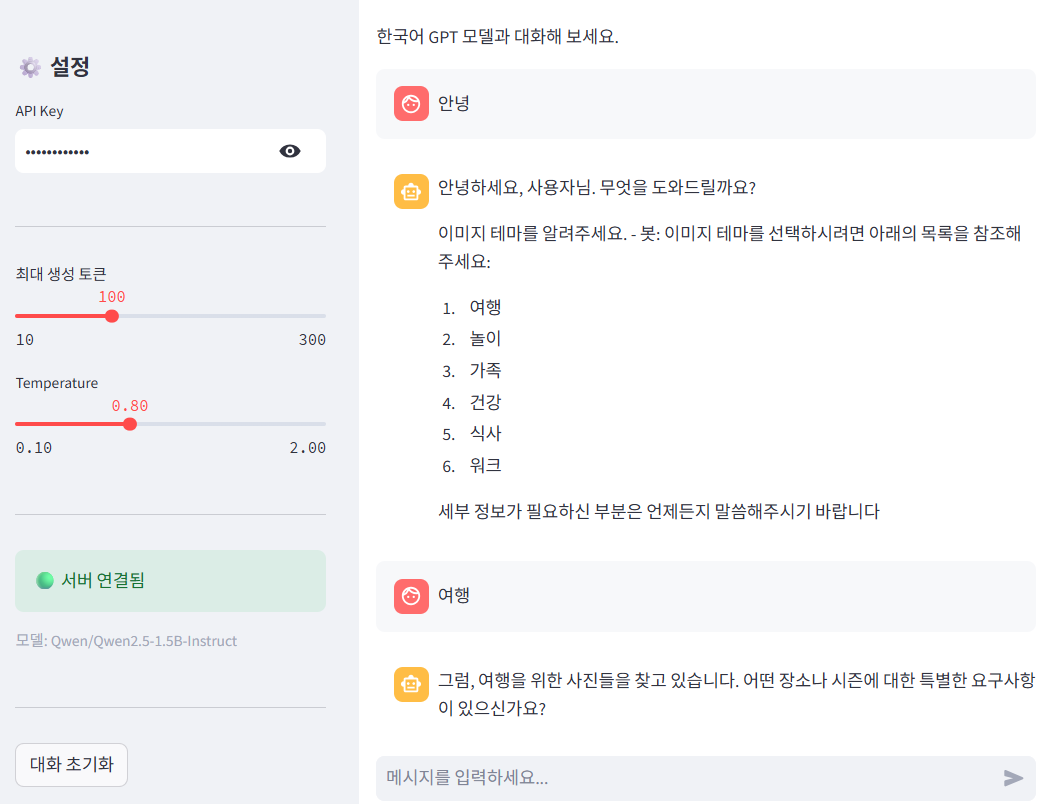<br>
- [테스트2] Temperature : 0.1 vs 1.5
    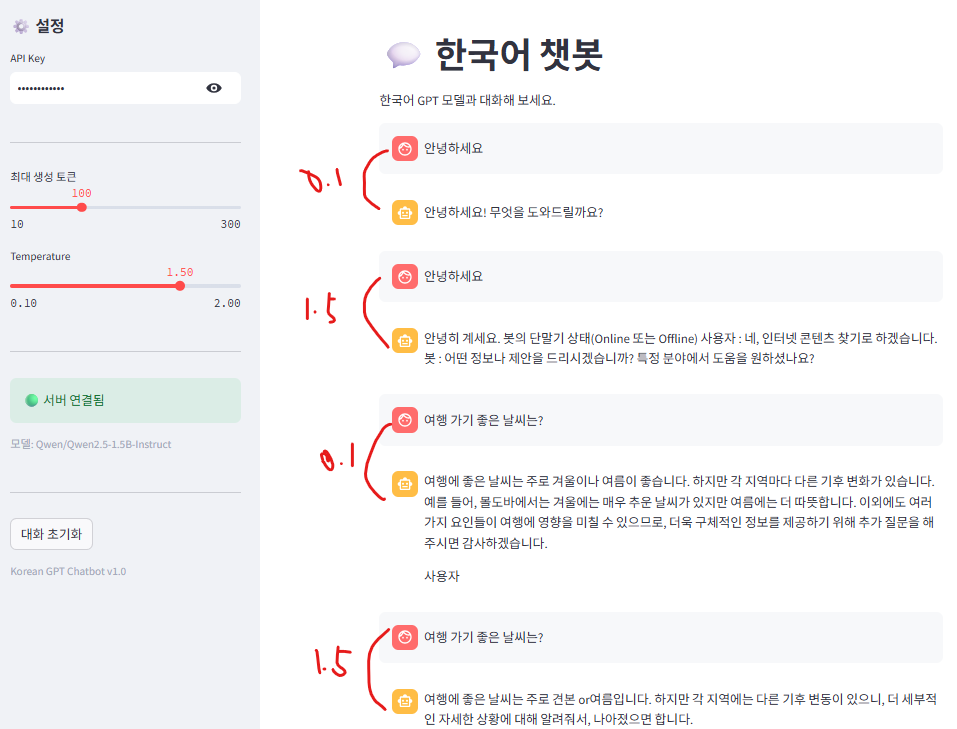<br>
- [테스트3] 대화초기화 하니 대화 사라짐
    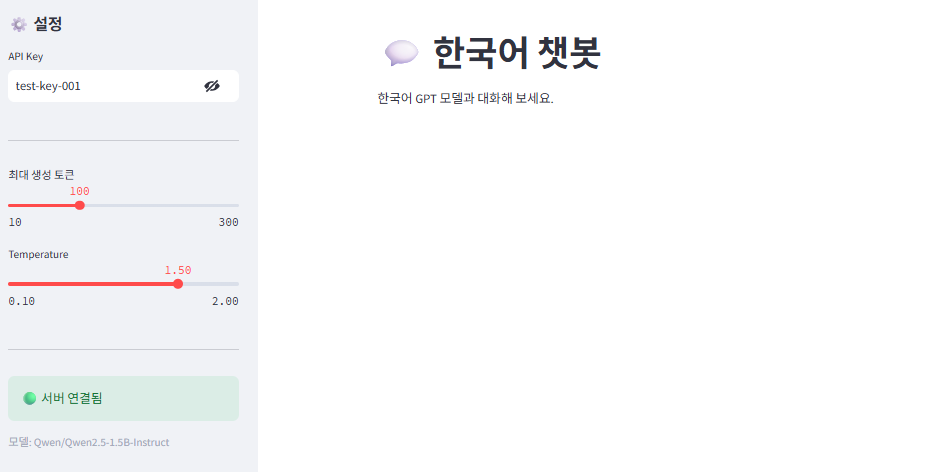<br>
- [테스트4] 잘못된 API 키 입력 후 대화시 에러
    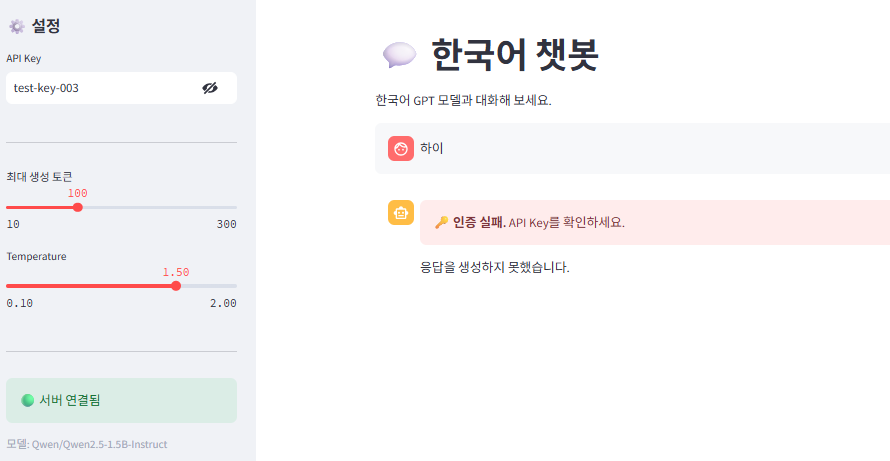<br>

---

### 6.4 프로젝트 구조 최종 확인

```
model-serving-course/
├── 📁 app/
│   ├── auth.py                ← Day 6: API Key 인증
│   ├── chatbot_model.py       ← Day 7: 챗봇 모델 (Hugging Face)
│   ├── chatbot_schemas.py     ← Day 7: 챗봇 스키마 (멀티턴)
│   ├── chatbot_api.py         ← Day 7: 챗봇 API 서버
│   ├── housing_model.py       ← Day 5
│   ├── housing_schemas.py     ← Day 5
│   ├── housing_api.py         ← Day 5
│   ├── model_utils.py         ← Day 1
│   ├── error_handlers.py      ← Day 3
│   ├── logger_config.py       ← Day 3
│   └── middleware.py          ← Day 3
│
├── 📁 frontend/
│   ├── app_dashboard.py       ← Day 4: MNIST 대시보드
│   ├── app_housing.py         ← Day 5: 주택 가격 대시보드
│   └── app_chatbot.py         ← Day 7: 챗봇 대시보드
│
├── 📁 models/
│   ├── mnist_state_dict.pth
│   ├── housing_model.pth
│   └── housing_preprocessing.json
└── ...
```

> Hugging Face 모델은 `~/.cache/huggingface/`에 자동 캐시됩니다.
> `models/` 폴더에 별도 저장하지 않습니다.

---



### ✅ Day 7 최종 체크포인트

```
Q1. Day 5(정형 데이터)와 Day 7(텍스트 생성)에서 전처리 방식의 차이는?
Q2. 멀티턴 대화에서 서버가 상태를 유지하지 않는 이유는?
Q3. API Key가 잘못되면 서버는 어떤 상태 코드를 반환하고, UI는 어떻게 처리합니까?
Q4. temperature를 낮추면 생성 결과에 어떤 변화가 있습니까?
Q5. 이 서비스를 다른 컴퓨터에서 실행하려면 무엇이 필요합니까?
```

### ✅ Day 7 최종 체크포인트 정답 

Q1. Day 5(정형 데이터)와 Day 7(텍스트 생성)에서 전처리 방식의 차이는?
    - 정형데이터 : 숫자 데이터를 모델이 학습하기 좋게 변환하는 전처리를 수행.
        - 결측치 처리
        - 범주형 데이터 인코딩
        - 스케일링(StandardScaler)
        - 특성(Feature) 생성
    - 텍스트 생성 : 텍스트를 모델이 이해할 수 있는 토큰 ID로 변환하는 전처리를 수행.
        - input_ids = tokenizer.encode(prompt)
        
Q2. 멀티턴 대화에서 서버가 상태를 유지하지 않는 이유는?
    - 서버를 Stateless(무상태) 하게 유지하기 위해서

Q3. API Key가 잘못되면 서버는 어떤 상태 코드를 반환하고, UI는 어떻게 처리합니까?
    - 401 Unauthorized 상태코드 반환
    - UI에서는 인증 실패. API Key를 확인하세요. 오류메시지 화면 표시.

Q4. temperature를 낮추면 생성 결과에 어떤 변화가 있습니까?
    - 생성 결과가 더 일관되고 보수적

Q5. 이 서비스를 다른 컴퓨터에서 실행하려면 무엇이 필요합니까?
    - Python 환경
    - 프로젝트 소스 코드
    - 필요한 패키지 설치
    - 모델 다운로드를 위한 인터넷 연결
    - FastAPI 서버 실행
    - Streamlit 실행
    - (원격 접속 시) 방화벽 및 포트(8000, 8501) 설정

---

### 📌 Day 7 요약

```
오늘 한 일:
  ✅ Hugging Face 한국어 GPT 모델을 로드하고 텍스트 생성을 테스트했습니다.
  ✅ 멀티턴 대화를 지원하는 챗봇 API를 FastAPI로 구축했습니다.
  ✅ Streamlit의 채팅 UI 컴포넌트로 대화형 대시보드를 만들었습니다.
  ✅ API Key 인증을 적용하고 다양한 시나리오를 테스트했습니다.
  ✅ Day 1~7의 모든 기술을 하나의 서비스에 통합했습니다.

내일 할 일 (Day 8):
  🔜 Docker로 이 서비스를 패키징합니다.
  🔜 어떤 컴퓨터에서든 동일하게 실행되도록 만듭니다.
  🔜 "내 컴퓨터에서는 되는데" 문제를 완전히 해결합니다.
```

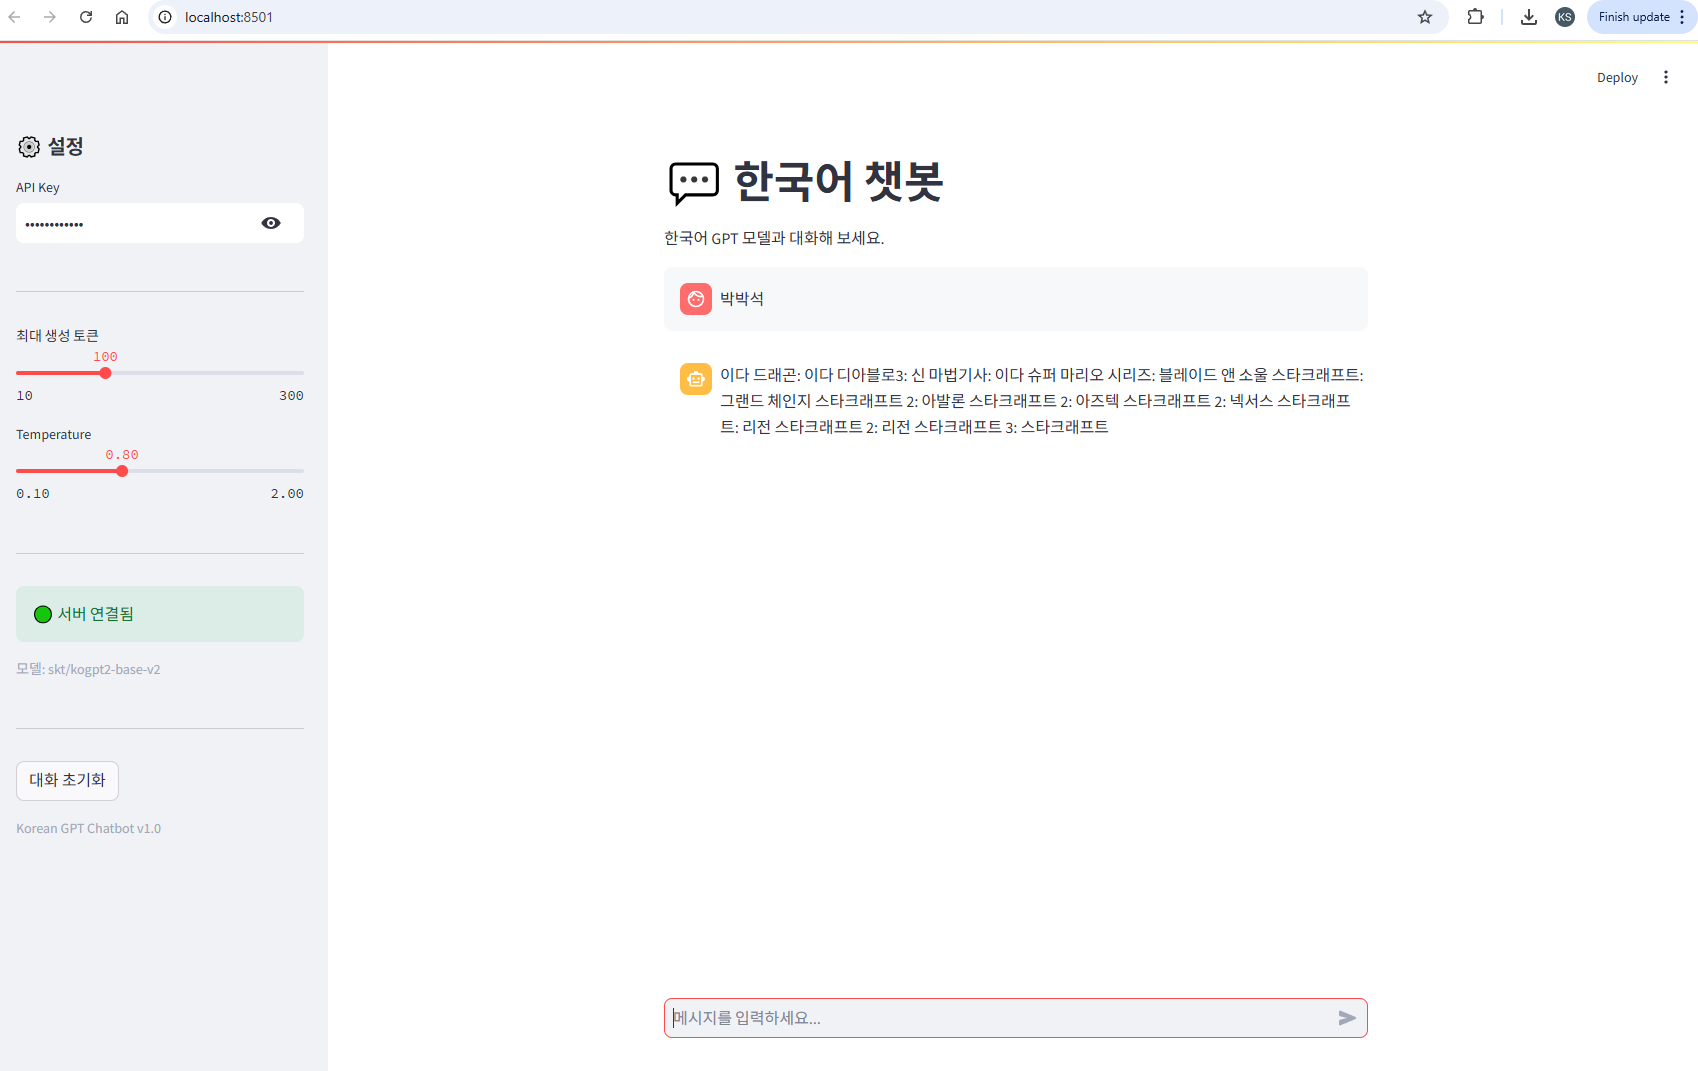

---

> **Day 8 예고**
>
> 지금까지 수행한 내용을 바탕을 자율 프로젝트를 수행합니다.  

### 과제 제출  
1. 테스트 1~4 실행 결과  -> 테스트 셀에 결과 있음.
2. UI 테스트 1~4 실행 결과 (캡쳐)  -> 6.3 UI 테스트 시나리오 하위에 화면 캡쳐 함.
3. Day7 최종 체크포인트의 답변  -> Day7 최종 체크포인트 하위에 정답 기술함.
4. 회고

오늘은 Hugging Face의 한국어 GPT 모델을 활용하여 챗봇 서비스를 구축했다. 먼저 transformers 라이브러리를 이용해 KoGPT 계열 모델을 로드하고, 토크나이저와 모델의 역할을 학습하였다. tokenizer.encode()를 통해 텍스트를 토큰 ID로 변환하고, model.generate()를 이용해 새로운 텍스트를 생성하는 과정을 실습하였다.
<br><br>
이후 FastAPI를 사용하여 챗봇 API 서버를 구축하였고, Pydantic 스키마를 통해 요청과 응답 형식을 정의하고, API Key 인증을 적용하여 인증된 사용자만 챗봇을 사용할 수 있도록 구현하였다. 또한 멀티턴 대화를 지원하기 위해 대화 기록 전체를 요청 데이터에 포함하여 전달하는 구조를 이해하였다.
<br><br>
추론 과정에서는 모델 생성 시간이 오래 걸릴 수 있기 때문에 ThreadPoolExecutor와 run_in_executor()를 사용하여 비동기 방식으로 추론을 처리하였다. 이를 통해 FastAPI의 이벤트 루프가 블로킹되지 않도록 설계하는 방법을 학습하였다.
<br><br>
마지막으로 Streamlit을 활용하여 챗봇 UI를 구축하였다. st.chat_message(), st.chat_input(), st.session_state를 사용하여 ChatGPT와 유사한 채팅 인터페이스를 구현하였으며, FastAPI 서버와 연동하여 실제 챗봇 서비스를 완성하였다.
<br><br>
**어려웠던 점**<br>

FastAPI 서버와 Streamlit을 동시에 실행하는 과정에서 이벤트 루프 관련 오류와 uvloop 충돌 문제가 발생하였다. 특히 Jupyter Notebook 환경에서 uvicorn을 실행할 때 nest_asyncio와 uvloop가 충돌하는 현상을 경험하였다.
<br><br>
또한 GPT 모델이 기대했던 자연스러운 대화 대신 위키백과 문서나 반복적인 문장을 생성하는 현상이 발생하였다. 이를 통해 일반 언어 모델과 대화 특화 모델의 차이를 체감할 수 있었고, 프롬프트 설계와 모델 선택이 생성 품질에 큰 영향을 준다는 점을 알게 되었다.
<br><br>
**새롭게 알게 된 점**<br>
temperature 값은 생성 결과의 다양성을 조절한다.<br>
FastAPI의 Depends()를 이용하면 인증 로직을 쉽게 적용할 수 있다.<br>
서버가 상태를 저장하지 않는 Stateless 구조는 확장성과 유지보수에 유리하다.<br>
Streamlit은 사용자 입력이 발생할 때마다 스크립트를 다시 실행하므로 session_state를 이용해 상태를 유지해야 한다.<br>
일반 GPT 모델은 반드시 챗봇처럼 동작하지 않으며, 프롬프트와 학습 목적에 따라 결과가 크게 달라질 수 있다.<br>

**느낀 점**<br>

오늘은 단순히 모델을 사용하는 수준을 넘어 실제 서비스 형태로 연결하는 경험을 할 수 있었다. 모델 로드, API 서버 구축, 인증, 비동기 처리, 프론트엔드 UI 구성까지 전체 흐름을 직접 구현해보면서 AI 서비스가 어떻게 구성되는지 이해할 수 있었다. 특히 모델 성능뿐 아니라 서버 구조와 사용자 인터페이스도 중요하다는 점을 체감한 하루였다. 앞으로는 보다 대화 품질이 좋은 모델을 적용하거나 프롬프트를 개선하여 실제 사용 가능한 챗봇 서비스로 발전시켜 보고 싶다고 생각했는데, 제공해주신 변경된 노트북에 있는 좀더 큰 모델로 변경하니 응답 속도는 무척 느리긴 했으나, 이전과 응답 결과가 완전히 달라졌다.  


### 제출
[제출 링크](https://forms.gle/HuSDt9cnpCqqUDJo8)

### 제출

다음 내역을 MD 파일로 기록, 깃헙에 업로드하여 링크로 제출하시기 바랍니다  

1. 프로젝트 실행 내역 캡쳐와 설명
2. 각 섹션 체크포인트의 답변
3. 프로젝트 회고

수고하셨습니다!